In [290]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load data
df = pd.read_csv('KC_housing_data.csv')

# HINT: Check structure first
print("\n----->head\n")
print(df.head())

print("\n----->shape\n")
print(df.shape)

print("\n----->data types/missing\n")
print(df.info())

print("\n----->numerical summary\n")
print(df.describe())

# Clean data
df = df[df["price"] >= 10000]



----->head

                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renovated          

3. Hypothesis: Homes without basements are more common among smaller, retirement-friendly houses. - Fabian \
-> True, as seen in the plot. \
-> 0 values on the lhs are missing entries in that range.

  sqft_bin  no_basement  percent_no_basement
0      350          1.0                100.0
1      400          1.0                100.0
2      450          1.0                100.0
3      500          1.0                100.0
4      550          1.0                100.0


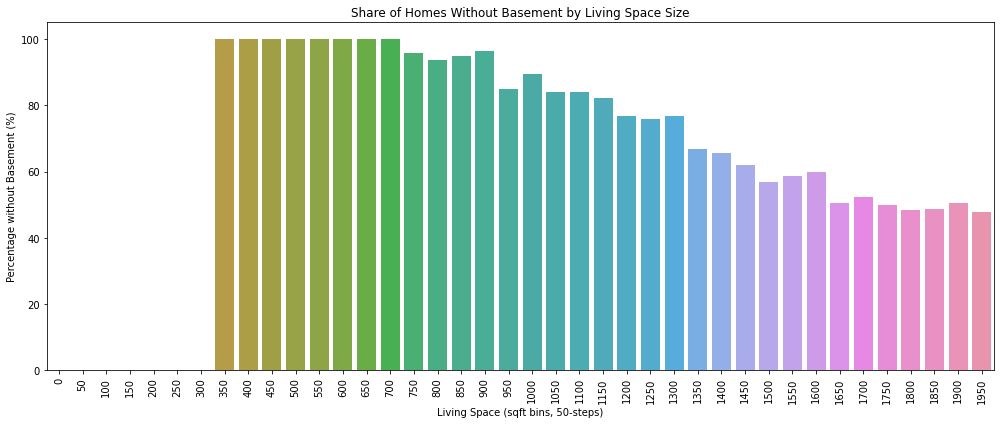

In [291]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

cutoff_sqft_living = 2000

# --- Filter data (cut at sqft_living) ---
df_filtered = df[df["sqft_living"] <= cutoff_sqft_living].copy()

# --- Create bins ---
bin_size = 50
bins = np.arange(0, cutoff_sqft_living + bin_size, bin_size)
labels = [f"{int(b)}" for b in bins[:-1]]

df_filtered["sqft_bin"] = pd.cut(
    df_filtered["sqft_living"],
    bins=bins,
    labels=labels,
    right=False
)

# --- Create basement indicator (1 = no basement, 0 = has basement) ---
df_filtered["no_basement"] = df_filtered["sqft_basement"] == 0

# --- Calculate percentage without basement per bin ---
# The average value of no_basement for each sqft_bin.
# True=1, False=0
percentage_df = (
    df_filtered
    .groupby("sqft_bin", observed=True)["no_basement"]
    .mean()
    .reset_index()
)

percentage_df["percent_no_basement"] = percentage_df["no_basement"] * 100

print(percentage_df.head())

# --- Plot ---
plt.figure(figsize=(14,6))

sns.barplot(
    data=percentage_df,
    x="sqft_bin",
    y="percent_no_basement"
)

plt.xticks(rotation=90)
plt.ylabel("Percentage without Basement (%)")
plt.xlabel(f"Living Space (sqft bins, {bin_size}-steps)")
plt.title("Share of Homes Without Basement by Living Space Size")
plt.tight_layout()
plt.show()


4. Hypothesis: Homes with no view are significantly more affordable. \
-> True

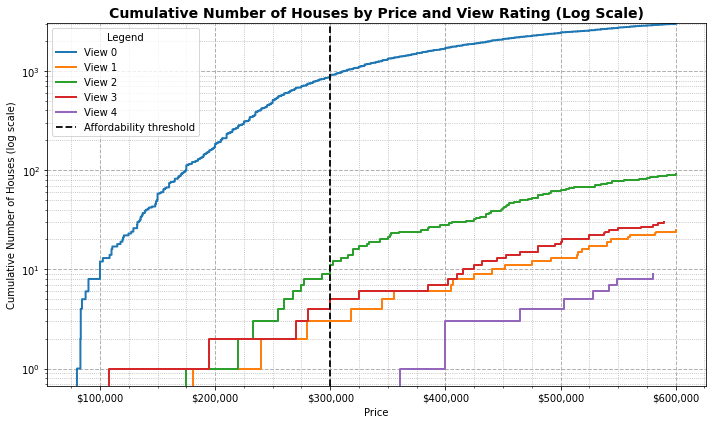

In [292]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, AutoMinorLocator

affordability_threshold = 300000
max_price = 2 * affordability_threshold

df_plot = df[df["price"] <= max_price]

plt.figure(figsize=(10,6))
palette = sns.color_palette("tab10", 5)

for i, view_level in enumerate(sorted(df_plot["view"].unique())):
    subset = df_plot[df_plot["view"] == view_level]
    
    sns.ecdfplot(
        data=subset,
        x="price",
        stat="count",
        label=f"View {view_level}",
        color=palette[i],
        linewidth=2
    )

# Log scale on y-axis
plt.yscale("log")

# Affordability threshold line
plt.axvline(
    affordability_threshold,
    color="black",
    linestyle="--",
    linewidth=1.8,
    label="Affordability threshold"
)

# Grid + minor ticks
ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
#ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.grid(True, which="major", linestyle="--", linewidth=1.0, alpha=1.0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.8, alpha=1.0)
ax.set_axisbelow(True)

# Dollar formatting
def dollar_formatter(x, pos):
    return f"${int(x):,}"

ax.xaxis.set_major_formatter(FuncFormatter(dollar_formatter))

plt.title(
    "Cumulative Number of Houses by Price and View Rating (Log Scale)",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Price")
plt.ylabel("Cumulative Number of Houses (log scale)")
plt.legend(title="Legend")

plt.tight_layout()

plt.savefig(
    "noView.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02,
    facecolor="white",
    transparent=False
)

plt.show()


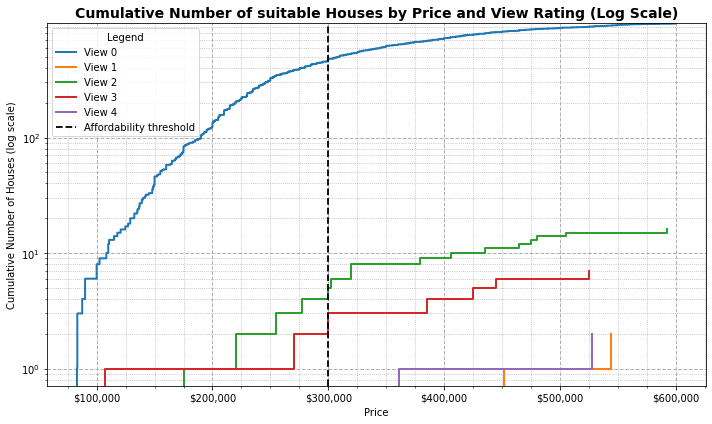

In [293]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, AutoMinorLocator

affordability_threshold = 300000
max_price = 2 * affordability_threshold

df_plot = df.copy()
df_plot = df_plot[df_plot["price"] <= max_price]
df_plot = df_plot[(df_plot["floors"] < 2) & (df_plot["sqft_basement"] <= 1)]
df_plot = df_plot[df_plot["condition"] >= 3]
df_plot = df_plot[df_plot["sqft_living"] <= 2000]

plt.figure(figsize=(10,6))
palette = sns.color_palette("tab10", 5)

for i, view_level in enumerate(sorted(df_plot["view"].unique())):
    subset = df_plot[df_plot["view"] == view_level]
    
    sns.ecdfplot(
        data=subset,
        x="price",
        stat="count",
        label=f"View {view_level}",
        color=palette[i],
        linewidth=2
    )

# Log scale on y-axis
plt.yscale("log")

# Affordability threshold line
plt.axvline(
    affordability_threshold,
    color="black",
    linestyle="--",
    linewidth=1.8,
    label="Affordability threshold"
)

# Grid + minor ticks
ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
#ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.grid(True, which="major", linestyle="--", linewidth=1.0, alpha=1.0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.8, alpha=1.0)
ax.set_axisbelow(True)

# Dollar formatting
def dollar_formatter(x, pos):
    return f"${int(x):,}"

ax.xaxis.set_major_formatter(FuncFormatter(dollar_formatter))

plt.title(
    "Cumulative Number of suitable Houses by Price and View Rating (Log Scale)",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Price")
plt.ylabel("Cumulative Number of Houses (log scale)")
plt.legend(title="Legend")

plt.tight_layout()

plt.savefig(
    "noView_filtered.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02,
    facecolor="white",
    transparent=False
)

plt.show()


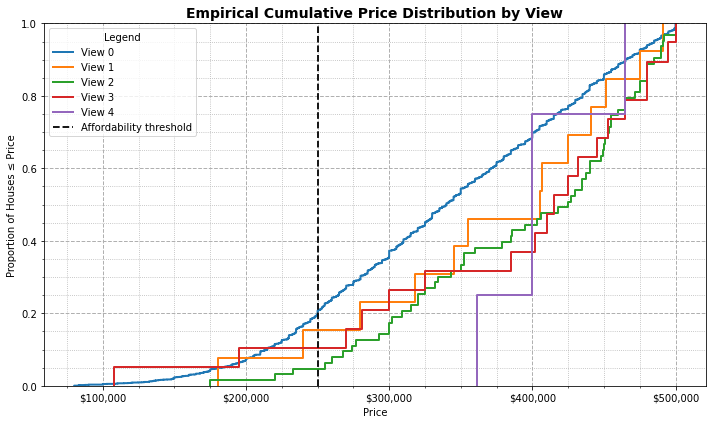

In [294]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, AutoMinorLocator

affordability_threshold = 250000
max_price = 2 * affordability_threshold

df_plot = df[df["price"] <= max_price]

plt.figure(figsize=(10,6))
palette = sns.color_palette("tab10", 5)

for i, view_level in enumerate(sorted(df_plot["view"].unique())):
    
    subset = df_plot[df_plot["view"] == view_level]
    
    sns.ecdfplot(
        data=subset,
        x="price",
        label=f"View {view_level}",
        color=palette[i],
        linewidth=2
    )

# Vertical affordability line
plt.axvline(
    affordability_threshold,
    color="black",
    linestyle="--",
    linewidth=1.8,
    label="Affordability threshold"
)

# Grid + minor ticks
ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.grid(True, which="major", linestyle="--", linewidth=1.0, alpha=1.0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.8, alpha=1.0)
ax.set_axisbelow(True)

# Dollar formatting
def dollar_formatter(x, pos):
    return f"${int(x):,}"

ax.xaxis.set_major_formatter(FuncFormatter(dollar_formatter))

plt.title(
    "Empirical Cumulative Price Distribution by View",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Price")
plt.ylabel("Proportion of Houses ≤ Price")
plt.legend(title="Legend")

plt.tight_layout()
plt.show()


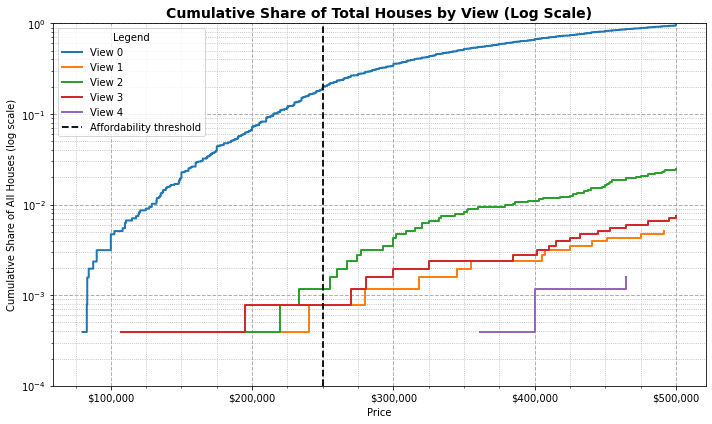

In [295]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, AutoMinorLocator

affordability_threshold = 250000
max_price = 2 * affordability_threshold

df_plot = df[df["price"] <= max_price]

N_total = len(df_plot)

plt.figure(figsize=(10,6))
palette = sns.color_palette("tab10", 5)

for i, view_level in enumerate(sorted(df_plot["view"].unique())):
    
    subset = (
        df_plot[df_plot["view"] == view_level]
        .sort_values("price")
    )
    
    prices = subset["price"].values
    N_view = len(prices)
    
    if N_view == 0:
        continue
    
    cumulative_count = np.arange(1, N_view + 1)
    cumulative_share_total = cumulative_count / N_total
    
    plt.step(
        prices,
        cumulative_share_total,
        where="post",
        label=f"View {view_level}",
        color=palette[i],
        linewidth=2
    )

# Log scale
plt.yscale("log")

# Avoid log(0)
plt.ylim(1e-4, 1)

# Affordability line
plt.axvline(
    affordability_threshold,
    color="black",
    linestyle="--",
    linewidth=1.8,
    label="Affordability threshold"
)

# Grid styling (only x minor locator — log y cannot use AutoMinorLocator)
ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.grid(True, which="major", linestyle="--", linewidth=1.0, alpha=1.0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.8, alpha=1.0)
ax.set_axisbelow(True)

# Dollar formatting
def dollar_formatter(x, pos):
    return f"${int(x):,}"

ax.xaxis.set_major_formatter(FuncFormatter(dollar_formatter))

plt.title(
    "Cumulative Share of Total Houses by View (Log Scale)",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Price")
plt.ylabel("Cumulative Share of All Houses (log scale)")
plt.legend(title="Legend")

plt.tight_layout()
plt.show()


BQ: When is the best time to buy or sell?


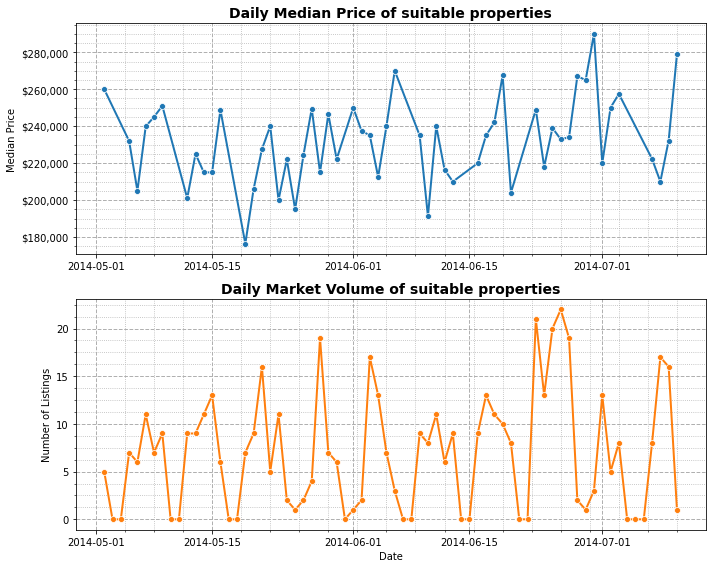

In [296]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, AutoMinorLocator

# -----------------------------
# Data Filtering
# -----------------------------
df_plot = df.copy()
df_plot = df_plot[df_plot["price"] <= 300000]
df_plot = df_plot[(df_plot["floors"] < 2) & (df_plot["sqft_basement"] <= 1)]
df_plot = df_plot[df_plot["condition"] >= 3]
df_plot = df_plot[df_plot["sqft_living"] <= 2000]

df_plot["date"] = pd.to_datetime(df_plot["date"])

# -----------------------------
# Daily Aggregation
# -----------------------------
df_daily = (
    df_plot
    .set_index("date")
    .resample("D")
    .agg({"price": ["median", "size"]})
)

df_daily.columns = ["median_price", "volume"]
df_daily = df_daily.reset_index()

# -----------------------------
# Plot
# -----------------------------
palette = sns.color_palette("tab10", 5)

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10,8),
    sharex=True
)

# ---- Top: Median Price ----
sns.lineplot(
    data=df_daily,
    x="date",
    y="median_price",
    color=palette[0],
    linewidth=2,
    ax=ax1,
	marker="o"
)

ax1.set_title(
    "Daily Median Price of suitable properties",
    fontsize=14,
    weight="bold"
)

ax1.set_ylabel("Median Price")
ax1.tick_params(labelbottom=True)

# Dollar formatting
def dollar_formatter(x, pos):
    return f"${int(x):,}"

ax1.yaxis.set_major_formatter(FuncFormatter(dollar_formatter))

ax1.xaxis.set_minor_locator(AutoMinorLocator(4))
ax1.yaxis.set_minor_locator(AutoMinorLocator(4))
ax1.grid(True, which="major", linestyle="--", linewidth=1.0, alpha=1.0)
ax1.grid(True, which="minor", linestyle=":", linewidth=0.8, alpha=1.0)
ax1.set_axisbelow(True)

# ---- Bottom: Volume ----
sns.lineplot(
    data=df_daily,
    x="date",
    y="volume",
    color=palette[1],
    linewidth=2,
    ax=ax2,
	marker="o"
)

ax2.set_title(
    "Daily Market Volume of suitable properties",
    fontsize=14,
    weight="bold"
)

ax2.set_xlabel("Date")
ax2.set_ylabel("Number of Listings")

ax2.xaxis.set_minor_locator(AutoMinorLocator(4))
ax2.yaxis.set_minor_locator(AutoMinorLocator(4))
ax2.grid(True, which="major", linestyle="--", linewidth=1.0, alpha=1.0)
ax2.grid(True, which="minor", linestyle=":", linewidth=0.8, alpha=1.0)
ax2.set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    "market.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02,
    facecolor="white",
    transparent=False
)

plt.show()


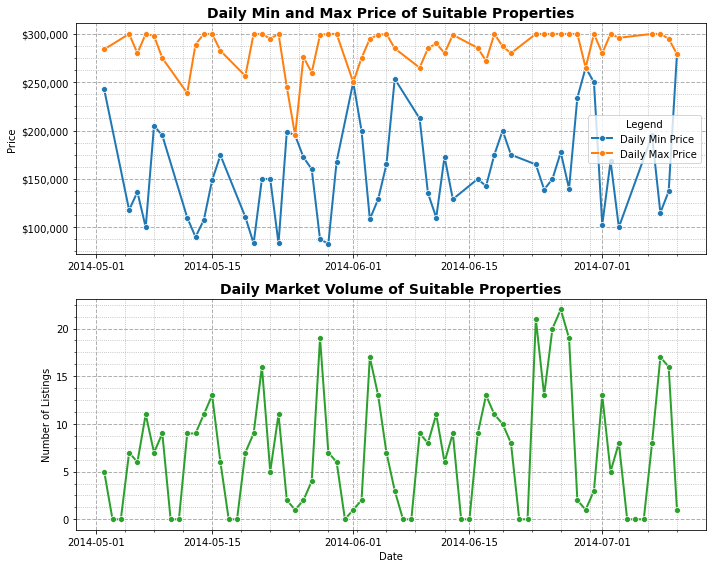

In [297]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, AutoMinorLocator

# -----------------------------
# Data Filtering
# -----------------------------
df_plot = df.copy()
df_plot = df_plot[df_plot["price"] <= 300000]
df_plot = df_plot[(df_plot["floors"] < 2) & (df_plot["sqft_basement"] <= 1)]
df_plot = df_plot[df_plot["condition"] >= 3]
df_plot = df_plot[df_plot["sqft_living"] <= 2000]

df_plot["date"] = pd.to_datetime(df_plot["date"])

# -----------------------------
# Daily Aggregation (min, max, volume)
# -----------------------------
df_daily = (
    df_plot
    .set_index("date")
    .resample("D")
    .agg({"price": ["min", "max", "size"]})
)

df_daily.columns = ["min_price", "max_price", "volume"]
df_daily = df_daily.reset_index()

# -----------------------------
# Plot
# -----------------------------
palette = sns.color_palette("tab10", 5)

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10,8),
    sharex=True
)

# ---- Top: Min & Max Price ----
sns.lineplot(
    data=df_daily,
    x="date",
    y="min_price",
    color=palette[0],
    linewidth=2,
    ax=ax1,
    marker="o",
    label="Daily Min Price"
)

sns.lineplot(
    data=df_daily,
    x="date",
    y="max_price",
    color=palette[1],
    linewidth=2,
    ax=ax1,
    marker="o",
    label="Daily Max Price"
)

ax1.set_title(
    "Daily Min and Max Price of Suitable Properties",
    fontsize=14,
    weight="bold"
)

ax1.set_ylabel("Price")
ax1.tick_params(labelbottom=True)

# Dollar formatting
def dollar_formatter(x, pos):
    return f"${int(x):,}"

ax1.yaxis.set_major_formatter(FuncFormatter(dollar_formatter))

ax1.xaxis.set_minor_locator(AutoMinorLocator(4))
ax1.yaxis.set_minor_locator(AutoMinorLocator(4))
ax1.grid(True, which="major", linestyle="--", linewidth=1.0, alpha=1.0)
ax1.grid(True, which="minor", linestyle=":", linewidth=0.8, alpha=1.0)
ax1.set_axisbelow(True)

ax1.legend(title="Legend")

# ---- Bottom: Volume ----
sns.lineplot(
    data=df_daily,
    x="date",
    y="volume",
    color=palette[2],
    linewidth=2,
    ax=ax2,
    marker="o"
)

ax2.set_title(
    "Daily Market Volume of Suitable Properties",
    fontsize=14,
    weight="bold"
)

ax2.set_xlabel("Date")
ax2.set_ylabel("Number of Listings")

ax2.xaxis.set_minor_locator(AutoMinorLocator(4))
ax2.yaxis.set_minor_locator(AutoMinorLocator(4))
ax2.grid(True, which="major", linestyle="--", linewidth=1.0, alpha=1.0)
ax2.grid(True, which="minor", linestyle=":", linewidth=0.8, alpha=1.0)
ax2.set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    "marketMinMax.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02,
    facecolor="white",
    transparent=False
)

plt.show()


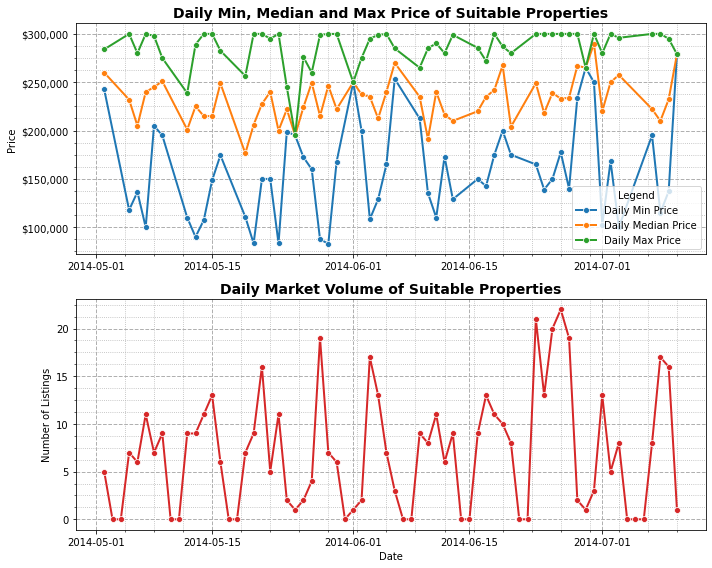

In [298]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, AutoMinorLocator

# -----------------------------
# Data Filtering
# -----------------------------
df_plot = df.copy()
df_plot = df_plot[df_plot["price"] <= 300000]
df_plot = df_plot[(df_plot["floors"] < 2) & (df_plot["sqft_basement"] <= 1)]
df_plot = df_plot[df_plot["condition"] >= 3]
df_plot = df_plot[df_plot["sqft_living"] <= 2000]

df_plot["date"] = pd.to_datetime(df_plot["date"])

# -----------------------------
# Daily Aggregation (min, median, max, volume)
# -----------------------------
df_daily = (
    df_plot
    .set_index("date")
    .resample("D")
    .agg({"price": ["min", "median", "max", "size"]})
)

df_daily.columns = ["min_price", "median_price", "max_price", "volume"]
df_daily = df_daily.reset_index()

# -----------------------------
# Plot
# -----------------------------
palette = sns.color_palette("tab10", 5)

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10,8),
    sharex=True
)

# ---- Top: Min, Median & Max Price ----
sns.lineplot(
    data=df_daily,
    x="date",
    y="min_price",
    color=palette[0],
    linewidth=2,
    ax=ax1,
    marker="o",
    label="Daily Min Price"
)

sns.lineplot(
    data=df_daily,
    x="date",
    y="median_price",
    color=palette[1],
    linewidth=2,
    ax=ax1,
    marker="o",
    label="Daily Median Price"
)

sns.lineplot(
    data=df_daily,
    x="date",
    y="max_price",
    color=palette[2],
    linewidth=2,
    ax=ax1,
    marker="o",
    label="Daily Max Price"
)

ax1.set_title(
    "Daily Min, Median and Max Price of Suitable Properties",
    fontsize=14,
    weight="bold"
)

ax1.set_ylabel("Price")
ax1.tick_params(labelbottom=True)

# Dollar formatting
def dollar_formatter(x, pos):
    return f"${int(x):,}"

ax1.yaxis.set_major_formatter(FuncFormatter(dollar_formatter))

ax1.xaxis.set_minor_locator(AutoMinorLocator(4))
ax1.yaxis.set_minor_locator(AutoMinorLocator(4))
ax1.grid(True, which="major", linestyle="--", linewidth=1.0, alpha=1.0)
ax1.grid(True, which="minor", linestyle=":", linewidth=0.8, alpha=1.0)
ax1.set_axisbelow(True)

ax1.legend(title="Legend")

# ---- Bottom: Volume ----
sns.lineplot(
    data=df_daily,
    x="date",
    y="volume",
    color=palette[3],
    linewidth=2,
    ax=ax2,
    marker="o"
)

ax2.set_title(
    "Daily Market Volume of Suitable Properties",
    fontsize=14,
    weight="bold"
)

ax2.set_xlabel("Date")
ax2.set_ylabel("Number of Listings")

ax2.xaxis.set_minor_locator(AutoMinorLocator(4))
ax2.yaxis.set_minor_locator(AutoMinorLocator(4))
ax2.grid(True, which="major", linestyle="--", linewidth=1.0, alpha=1.0)
ax2.grid(True, which="minor", linestyle=":", linewidth=0.8, alpha=1.0)
ax2.set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    "marketMinMedianMax.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02,
    facecolor="white",
    transparent=False
)

plt.show()
